In [3]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

lat_indices = np.linspace(90, -90, 721)
lon_indices = np.linspace(-180, 180, 1441)[:-1]
pres_list = ['1000','925','850','700','600','500','400','300','250','200','150','100','50']
def latlon_extent(lon_min, lon_max, lat_min, lat_max, part = 'y'):    
    # lon_min, lon_max = lon_min, lon_max  
    if part == 'y':
        lat_indices = np.arange(lat_min, lat_max+0.1, 0.25)[::-1]
        lon_indices = np.arange(lon_min, lon_max+0.1, 0.25)
    else:
        lat_indices = np.linspace(90, -90, 721)
        lon_indices = np.concatenate((np.linspace(0, 180, 721), np.linspace(-180, 0, 721)[1:-1]),axis=0)
    # 위경도 범위를 데이터의 행과 열 인덱스로 변환
    lat_start = np.argmin(np.abs(lat_indices - lat_max)) 
    lat_end = np.argmin(np.abs(lat_indices - lat_min))
    lon_start = np.argmin(np.abs(lon_indices - lon_min))
    lon_end = np.argmin(np.abs(lon_indices - lon_max))
    latlon_ratio = (lon_max-lon_min)/(lat_max-lat_min)
    extent=[lon_min, lon_max, lat_min, lat_max]
    return lat_indices, lat_start, lat_end, lon_indices, lon_start, lon_end, extent, latlon_ratio

lat_indices, lat_start, lat_end, lon_indices, lon_start, lon_end, extent, latlon_ratio = latlon_extent(100,160,5,45)  
lon_grid, lat_grid = np.meshgrid(lon_indices[lon_start:lon_end + 1], lat_indices[lat_start:lat_end + 1])

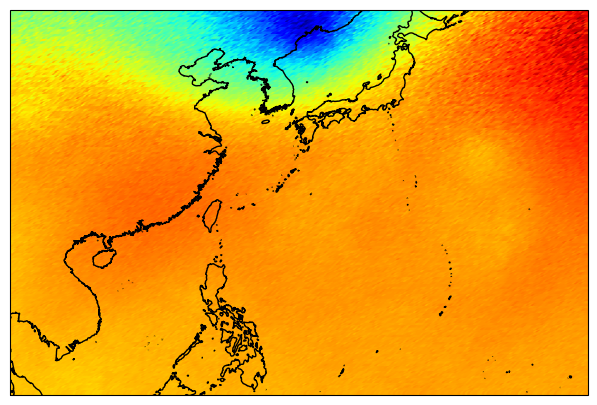

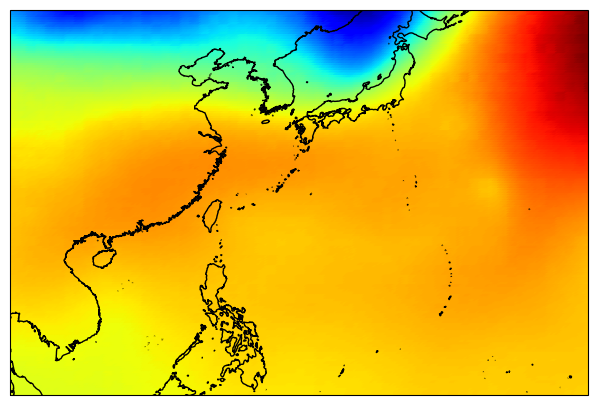

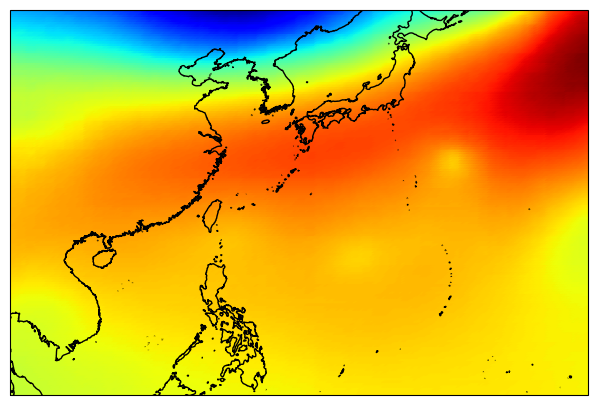

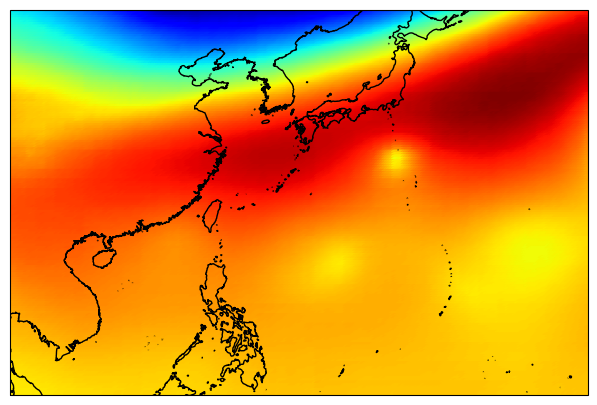

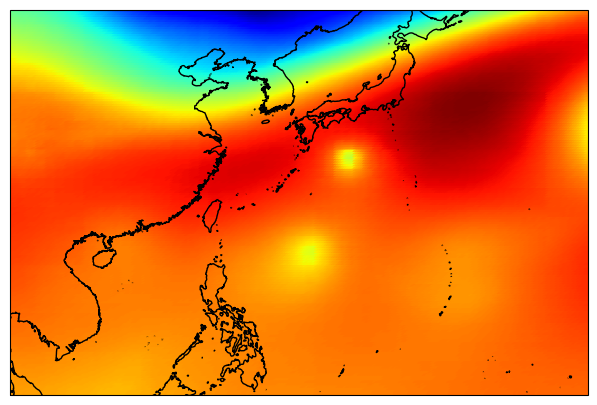

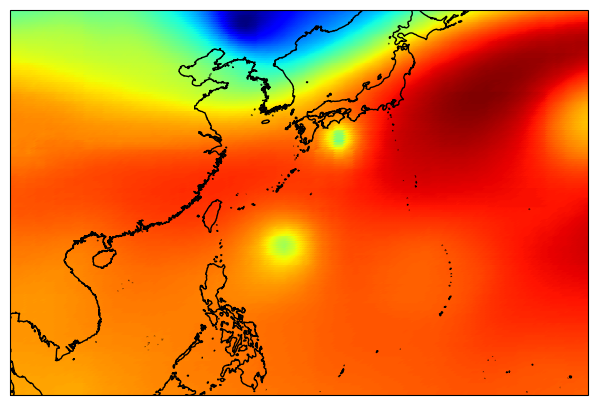

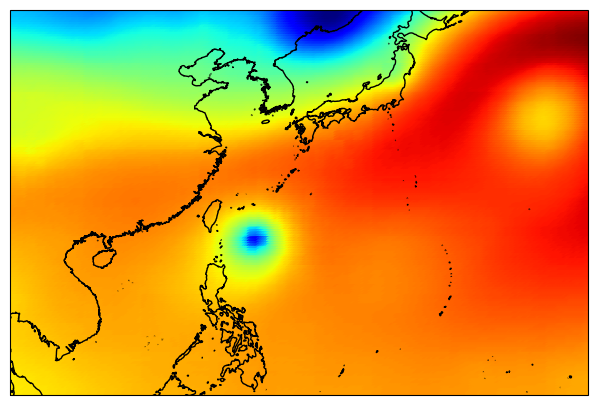

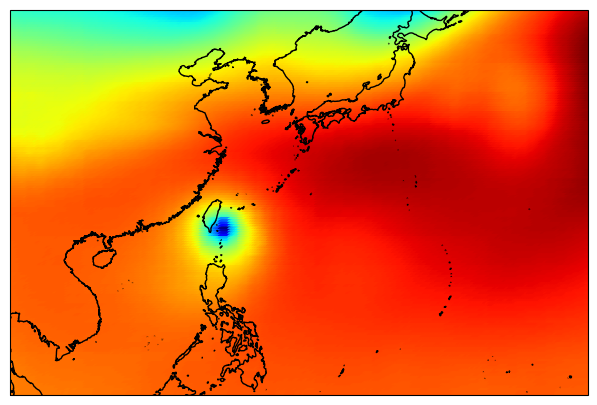

In [22]:
ens_num = 110
pres = 500


for interval_hour in ['0','24', '48', '72', '96', '120', '144', '168']:
    upper_data = np.load(f"/data03/Pangu_TC_ENS/output_data/2022/08/27/00UTC/0.2ENS_z_lp/{ens_num}/upper/{interval_hour}h.npy")
    fig, ax = plt.subplots(figsize=(5*latlon_ratio,5), subplot_kw={'projection': ccrs.PlateCarree()})
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.coastlines(resolution='10m', color='black', linewidth=1)
    ax.scatter(lon_grid, lat_grid, c = upper_data[0,pres_list.index(str(pres))], cmap='jet')
    plt.show()
# plt.imshow(upper_data_8[0,0] - upper_data_9[0,0])